In [ ]:
!unzip cats_dogs_dataset.zip

Archive:  cats_dogs_dataset.zip
   creating: cats_dogs_dataset/
   creating: cats_dogs_dataset/test/
   creating: cats_dogs_dataset/test/cats/
  inflating: cats_dogs_dataset/test/cats/233.jpg  
  inflating: cats_dogs_dataset/test/cats/234.jpg  
  inflating: cats_dogs_dataset/test/cats/235.jpg  
  inflating: cats_dogs_dataset/test/cats/236.jpg  
  inflating: cats_dogs_dataset/test/cats/237.jpg  
  inflating: cats_dogs_dataset/test/cats/238.jpg  
  inflating: cats_dogs_dataset/test/cats/239.jpg  
  inflating: cats_dogs_dataset/test/cats/24.jpg  
  inflating: cats_dogs_dataset/test/cats/240.jpg  
  inflating: cats_dogs_dataset/test/cats/241.jpg  
  inflating: cats_dogs_dataset/test/cats/242.jpg  
  inflating: cats_dogs_dataset/test/cats/243.jpg  
  inflating: cats_dogs_dataset/test/cats/244.jpg  
  inflating: cats_dogs_dataset/test/cats/245.jpg  
  inflating: cats_dogs_dataset/test/cats/246.jpg  
  inflating: cats_dogs_dataset/test/cats/247.jpg  
  inflating: cats_dogs_dataset/test/cats/2

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable weights before freezing: 30
Trainable weights after freezing: 4
Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/30
 68/100 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.6308 - loss: 0.6418

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 344ms/step - accuracy: 0.7030 - loss: 0.5812 - val_accuracy: 0.8700 - val_loss: 0.4011
Epoch 2/30
  1/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.6250 - loss: 0.5862

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7668 - loss: 0.5084 - val_accuracy: 0.8775 - val_loss: 0.3866
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 256ms/step - accuracy: 0.8014 - loss: 0.4547 - val_accuracy: 0.8700 - val_loss: 0.3312
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8101 - loss: 0.4304 - val_accuracy: 0.8700 - val_loss: 0.3180
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 256ms/step - accuracy: 0.8140 - loss: 0.4112 - val_accuracy: 0.9050 - val_loss: 0.2783
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8365 - loss: 0.3956 - val_accuracy: 0.8775 - val_loss: 0.2951
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.8344 - loss: 0.3823 - val_accuracy: 0.8800 - val_loss: 0.2780
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8029 - loss: 0.3918 - val_accuracy: 0.8975 - val_loss: 0.2657
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.8369 - loss: 0.3608 - val_accurac

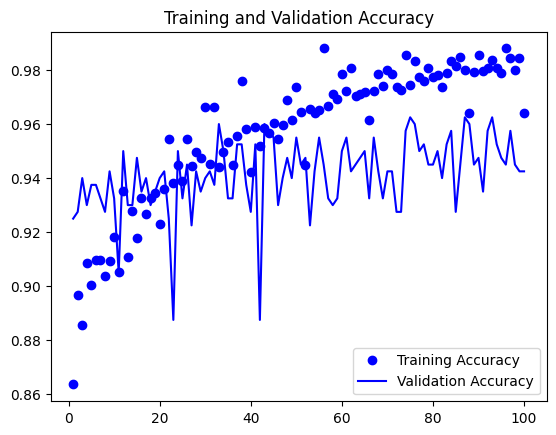

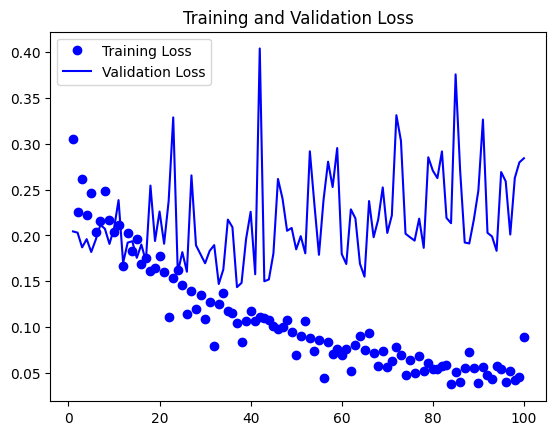

In [ ]:
# Transfer Learning + Fine Tuning using VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load pretrained VGG16 convolution base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

# Build model
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Freeze convolution base
print("Trainable weights before freezing:", len(model.trainable_weights))
conv_base.trainable = False
print("Trainable weights after freezing:", len(model.trainable_weights))


# Dataset directories
train_dir="/content/cats_dogs_dataset/train/"
validation_dir="/content/cats_dogs_dataset/validation/"

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Compile model (initial training)
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=['accuracy']
)

# Train top classifier
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

# ------------------------
# Fine Tuning
# ------------------------

conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    layer.trainable = set_trainable

# Recompile with lower learning rate
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    metrics=['accuracy']
)

# Fine-tune training
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50
)

# Plot results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()